# HW4 — 自回归图像块生成（Autoregressive Patch Generation）
**「模型能学会一次画一个图像块（patch）吗？」**

本 notebook 按里程碑分节，自上而下干净运行。每个 patch（8×8 图像块）被量化成一个离散
token，模型在 patch 词表上做 softmax 预测下一个 patch —— 即「图像版 GPT / patch 级 PixelCNN」。

> **运行环境：** 请将内核选为 conda 环境 **`AgentHallucination`**
> （`/home/zaitpub04/anaconda3/envs/AgentHallucination`，torch 2.10.0+cu128，8×RTX 4090）。
> 不依赖 torchvision：CIFAR-10 直接从本地 pickle 加载，上采样用 `F.interpolate`。

**阶段进度**
1. ✅ 图像 tokenize（patch 提取 + 位置编码） —— *本节*
2. ⬜ 因果 Transformer（预测下一个 patch token）
3. ⬜ 自回归采样 + 注意力时间线
4. ⬜ VAE 对比
5. ⬜ 开放探究 + AI 使用日志

## 0. 环境与全局配置

所有形状常量集中在 `CFG`，下游阶段共用。`artifacts/` 缓存码本、token 序列、位置编码，
使 cell 幂等：已生成则直接加载，避免重复计算。

In [4]:
import os, math, time, pickle, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = dict(
    img_size   = 64,        # CIFAR-10 上采样后的边长
    patch      = 8,         # patch 边长 → 8×8
    grid       = 8,         # 每行/列 patch 数 (64/8)
    n_patches  = 64,        # 每图 patch 数 (8×8)
    patch_dim  = 8*8*3,     # 一个 patch 拉平后的维度 = 192
    vocab_k    = 512,       # 码本大小：patch 词表中「真实 patch」token 数
    bos_id     = 512,       # BOS token id = K（排在所有 patch token 之后）
    vocab_size = 513,       # K + 1（含 BOS）
    seq_len    = 65,        # 序列长度：BOS + 64 个 patch
    d_model    = 256,       # 位置编码 / Transformer 隐藏维度
)

CIFAR_ROOT = "/home/zaitpub04/hyj/ai_hw/hw5/data/cifar-10-batches-py"
ART = Path("artifacts"); ART.mkdir(exist_ok=True)

print("device:", DEVICE, "| torch", torch.__version__)
for k, v in CFG.items():
    print(f"  {k:10s} = {v}")

device: cuda | torch 2.10.0+cu128
  img_size   = 64
  patch      = 8
  grid       = 8
  n_patches  = 64
  patch_dim  = 192
  vocab_k    = 512
  bos_id     = 512
  vocab_size = 513
  seq_len    = 65
  d_model    = 256


## 里程碑 1 — 图像 Tokenize（patch 提取 + 位置编码）

**目标：** 把一张图变成一串离散 token，让因果 Transformer 能像处理文字一样处理它。

四步：
1. **加载 + 上采样**：CIFAR-10 32×32 → 双线性上采样到 64×64。
2. **patch 提取**：按 raster 顺序（从左到右、从上到下）切成 64 个 8×8 patch；可无损还原。
3. **建词表（codebook）**：softmax 预测头要求 patch 是*离散* token，所以用 **K-means** 在
   训练集 patch 上聚出 K=512 个质心；每个 patch → 最近质心索引 = token id。前置 BOS。
4. **位置编码**：正弦位置编码——自回归生成顺序很重要。

> **为什么用 K-means 而不是学一个 VQ-VAE？** 量化只需把 patch 离散化；K-means 码本简单、
> 确定、可复现，且**不与里程碑 4 的 VAE 基线在架构上重叠**（保证对比公平）。代价是有一个
> *量化上限*——重构无法超过码本精度，我们会量化出这个上限作为 Transformer 样本质量的天花板。

### 1.1 加载 CIFAR-10 并上采样到 64×64

In [5]:
def load_cifar(root):
    def _load(fn):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # numpy2 对 pickle dtype 的无害告警
            with open(os.path.join(root, fn), "rb") as f:
                d = pickle.load(f, encoding="bytes")
        return d[b"data"], np.array(d[b"labels"])
    xs, ys = [], []
    for i in range(1, 6):
        x, y = _load(f"data_batch_{i}"); xs.append(x); ys.append(y)
    train_x = np.concatenate(xs).reshape(-1, 3, 32, 32)
    train_y = np.concatenate(ys)
    tex, tey = _load("test_batch")
    test_x = tex.reshape(-1, 3, 32, 32); test_y = tey
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with open(os.path.join(root, "batches.meta"), "rb") as f:
            classes = [n.decode() for n in pickle.load(f, encoding="bytes")[b"label_names"]]
    return train_x, train_y, test_x, test_y, classes

train_x32, train_y, test_x32, test_y, CLASSES = load_cifar(CIFAR_ROOT)
np.save(ART/"train_y.npy", train_y); np.save(ART/"test_y.npy", test_y)
print("train", train_x32.shape, "| test", test_x32.shape)
print("classes:", CLASSES)

@torch.no_grad()
def upsample_batch(x_uint8, size=CFG["img_size"], device=DEVICE):
    '''(B,3,32,32) uint8 → (B,3,size,size) float in [0,1]，双线性上采样，结果在 device 上。'''
    x = torch.from_numpy(np.ascontiguousarray(x_uint8)).float().div(255.).to(device)
    return F.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)

train (50000, 3, 32, 32) | test (10000, 3, 32, 32)
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


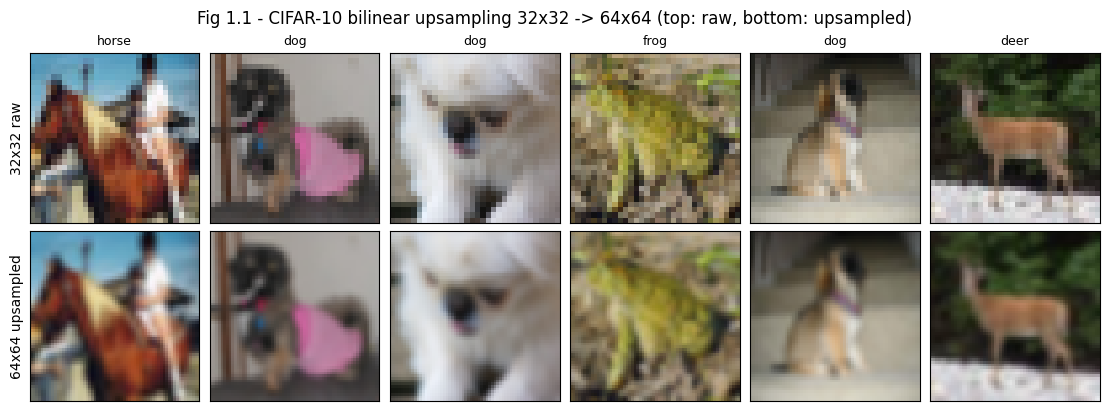

一句话说明：上采样到 64×64 后每图恰好可切成 8×8=64 个 8×8 patch；
           双线性上采样只是变平滑、不增加真实细节，所以两排看起来很接近是正常的。


In [6]:
# 视觉 sanity check：原图 vs 上采样（真正的上采样在 upsample_batch 里的 F.interpolate）
idx = np.random.RandomState(SEED).choice(len(train_x32), 6, replace=False)
raw = torch.from_numpy(train_x32[idx]).float().div(255.)      # 32x32 原图（仅归一化）
up  = upsample_batch(train_x32[idx]).cpu()                    # 64x64 上采样后
fig, axes = plt.subplots(2, 6, figsize=(11, 4), constrained_layout=True)
for j in range(6):
    axes[0, j].imshow(raw[j].permute(1, 2, 0).numpy(), interpolation="nearest")
    axes[0, j].set_title(CLASSES[train_y[idx[j]]], fontsize=9)
    axes[1, j].imshow(up[j].permute(1, 2, 0).clamp(0, 1).numpy(), interpolation="nearest")
    for r in (0, 1):
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])   # 留住坐标轴以显示行标签，只去刻度
axes[0, 0].set_ylabel("32x32 raw", fontsize=10)
axes[1, 0].set_ylabel("64x64 upsampled", fontsize=10)
fig.suptitle("Fig 1.1 - CIFAR-10 bilinear upsampling 32x32 -> 64x64 (top: raw, bottom: upsampled)")
plt.show()
print("一句话说明：上采样到 64×64 后每图恰好可切成 8×8=64 个 8×8 patch；")
print("           双线性上采样只是变平滑、不增加真实细节，所以两排看起来很接近是正常的。")

### 1.2 patch 提取与还原（patchify / unpatchify）

按 **raster 顺序**（从左到右、从上到下）切分——这就是自回归生成顺序。patch 向量内部布局为
`(C, p, p)`。下面的往返测试断言切分**完全可逆**（无损），保证 token 化没有丢失结构信息。

In [7]:
def patchify(x, p=CFG["patch"]):
    '''(B,C,H,W) → (B, n_patches, C*p*p)，raster 顺序。'''
    B, C, H, W = x.shape
    gh, gw = H // p, W // p
    x = x.reshape(B, C, gh, p, gw, p).permute(0, 2, 4, 1, 3, 5).reshape(B, gh*gw, C*p*p)
    return x

def unpatchify(patches, p=CFG["patch"], c=3, grid=CFG["grid"]):
    '''(B, n_patches, C*p*p) → (B,C,H,W)，patchify 的逆。'''
    B, N, D = patches.shape
    x = patches.reshape(B, grid, grid, c, p, p).permute(0, 3, 1, 4, 2, 5).reshape(B, c, grid*p, grid*p)
    return x

# 往返无损测试
_x = upsample_batch(train_x32[:4])
_err = (_x - unpatchify(patchify(_x))).abs().max().item()
print(f"patchify/unpatchify 最大绝对误差 = {_err:.2e}")
assert _err < 1e-6, "patch 切分不可逆——顺序或 reshape 有 bug！"
print("✓ patch 提取可无损还原（raster 顺序：从左到右、从上到下）")

patchify/unpatchify 最大绝对误差 = 0.00e+00
✓ patch 提取可无损还原（raster 顺序：从左到右、从上到下）


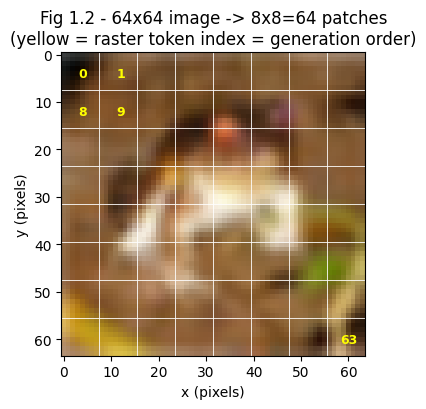

一句话说明：token 0 在左上角，沿行递增，token 63 在右下角——即模型的生成顺序。


In [8]:
# 可视化一张图的 patch 网格与 raster token 序号
img = upsample_batch(train_x32[:1])[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy()
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.imshow(img, interpolation="nearest")
for k in range(1, CFG["grid"]):
    ax.axhline(k*CFG["patch"]-0.5, color="w", lw=0.6)
    ax.axvline(k*CFG["patch"]-0.5, color="w", lw=0.6)
for n in [0, 1, 8, 9, 63]:
    r, c = divmod(n, CFG["grid"])
    ax.text(c*CFG["patch"]+4, r*CFG["patch"]+4, str(n),
            color="yellow", ha="center", va="center", fontsize=9, weight="bold")
ax.set_xlabel("x (pixels)"); ax.set_ylabel("y (pixels)")
ax.set_title("Fig 1.2 - 64x64 image -> 8x8=64 patches\n(yellow = raster token index = generation order)")
plt.tight_layout(); plt.show()
print("一句话说明：token 0 在左上角，沿行递增，token 63 在右下角——即模型的生成顺序。")

### 1.3 用 K-means 建 patch 词表（codebook）

在训练集 patch 上拟合 K-means（K=512），质心即「视觉词」。每个 patch 映射到最近质心的索引
（token id ∈ 0..511），BOS 用 id 512。已缓存则直接加载。

In [9]:
from sklearn.cluster import MiniBatchKMeans

CODEBOOK_PATH = ART / f"codebook_k{CFG['vocab_k']}.npy"
if CODEBOOK_PATH.exists():
    codebook = np.load(CODEBOOK_PATH)
    print("已加载缓存码本", codebook.shape)
else:
    n_sample_imgs = 8000  # 8000 图 × 64 ≈ 51 万 patch 足够拟合 512 个质心
    sel = np.random.RandomState(SEED).choice(len(train_x32), n_sample_imgs, replace=False)
    chunks = []
    for i in range(0, n_sample_imgs, 1000):
        xb = upsample_batch(train_x32[sel[i:i+1000]])
        chunks.append(patchify(xb).reshape(-1, CFG["patch_dim"]).cpu().numpy())
    patches = np.concatenate(chunks)
    print("在", patches.shape, "个 patch 上拟合 K-means ...")
    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=CFG["vocab_k"], batch_size=4096,
                         n_init=3, max_iter=200, random_state=SEED)
    km.fit(patches)
    codebook = km.cluster_centers_.astype(np.float32)
    np.save(CODEBOOK_PATH, codebook)
    print(f"完成，用时 {time.time()-t0:.1f}s；码本 {codebook.shape}")

codebook_t = torch.from_numpy(codebook).to(DEVICE)      # (K, 192)
cb_sqnorm  = (codebook_t**2).sum(1)                      # (K,) 预算平方范数

@torch.no_grad()
def quantize_patches(patches):
    '''(M,192) on device → 最近质心 id (M,)，用 ||p-c||^2 = ||p||^2 - 2p·c + ||c||^2。'''
    d = -2.0 * patches @ codebook_t.T + cb_sqnorm[None, :]
    return d.argmin(1)

在 (512000, 192) 个 patch 上拟合 K-means ...


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


完成，用时 26.2s；码本 (512, 192)


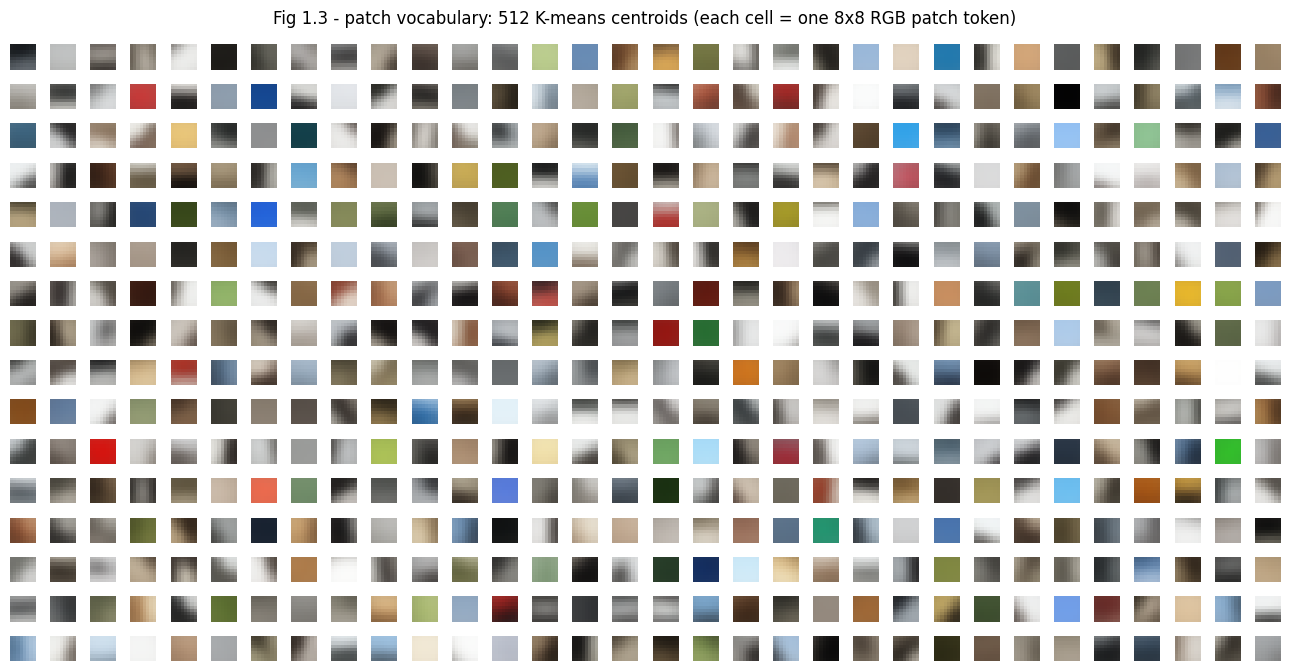

一句话说明：词表里多是平滑色块与简单边缘——这决定了 token 化能表达的视觉细节上限。


In [10]:
# 可视化整个 patch 词表（512 个质心 patch）
cb_imgs = codebook.reshape(-1, 3, CFG["patch"], CFG["patch"])
fig, axes = plt.subplots(16, 32, figsize=(13, 6.8))
for k, ax in enumerate(axes.flat):
    ax.imshow(np.clip(cb_imgs[k].transpose(1, 2, 0), 0, 1), interpolation="nearest")
    ax.axis("off")
fig.suptitle(f"Fig 1.3 - patch vocabulary: {CFG['vocab_k']} K-means centroids (each cell = one 8x8 RGB patch token)")
plt.tight_layout(); plt.show()
print("一句话说明：词表里多是平滑色块与简单边缘——这决定了 token 化能表达的视觉细节上限。")

### 1.4 Tokenize / Detokenize 整个数据集

把训练/测试集全部转成 token 序列 `(N, 65)`（第 0 列是 BOS）。然后反量化重构，量化出**测试集
重构 MSE/PSNR**——这是 Transformer 样本质量的*理论上限*（它再好也超不过码本）。

In [11]:
@torch.no_grad()
def tokenize_images(x32, bs=2000):
    out = []
    for i in range(0, len(x32), bs):
        xb = upsample_batch(x32[i:i+bs])
        ids = quantize_patches(patchify(xb).reshape(-1, CFG["patch_dim"]))
        out.append(ids.reshape(-1, CFG["n_patches"]).cpu())
    ids = torch.cat(out).to(torch.int16)
    bos = torch.full((len(ids), 1), CFG["bos_id"], dtype=torch.int16)
    return torch.cat([bos, ids], 1)            # (N, 65)

TOK_TR, TOK_TE = ART/"train_tokens.pt", ART/"test_tokens.pt"
if TOK_TR.exists() and TOK_TE.exists():
    train_tokens = torch.load(TOK_TR); test_tokens = torch.load(TOK_TE)
    print("已加载缓存 token")
else:
    t0 = time.time()
    train_tokens = tokenize_images(train_x32); test_tokens = tokenize_images(test_x32)
    torch.save(train_tokens, TOK_TR); torch.save(test_tokens, TOK_TE)
    print(f"tokenize 完成，用时 {time.time()-t0:.1f}s")
print("train_tokens", tuple(train_tokens.shape), "| test_tokens", tuple(test_tokens.shape))
print("token 取值范围", int(train_tokens.min()), "..", int(train_tokens.max()),
      f"(BOS id = {CFG['bos_id']})")

@torch.no_grad()
def detokenize(tokens):
    '''(B,65) 含 BOS → 图像 (B,3,64,64)。'''
    ids = tokens[:, 1:].long().to(DEVICE)       # 去掉 BOS
    return unpatchify(codebook_t[ids]).clamp(0, 1)

@torch.no_grad()
def quant_mse(x32, tokens, bs=2000):
    se, n = 0.0, 0
    for i in range(0, len(x32), bs):
        orig = upsample_batch(x32[i:i+bs]); rec = detokenize(tokens[i:i+bs])
        se += ((orig - rec)**2).sum().item(); n += orig.numel()
    return se / n

qmse = quant_mse(test_x32, test_tokens)
qpsnr = 10 * math.log10(1.0 / qmse)
print(f"\n量化上限（测试集）: MSE={qmse:.5f}  PSNR={qpsnr:.2f} dB")
print("→ Transformer 的重构/样本质量不可能超过这个码本量化上限。")

tokenize 完成，用时 2.1s
train_tokens (50000, 65) | test_tokens (10000, 65)
token 取值范围 0 .. 512 (BOS id = 512)

量化上限（测试集）: MSE=0.00451  PSNR=23.45 dB
→ Transformer 的重构/样本质量不可能超过这个码本量化上限。


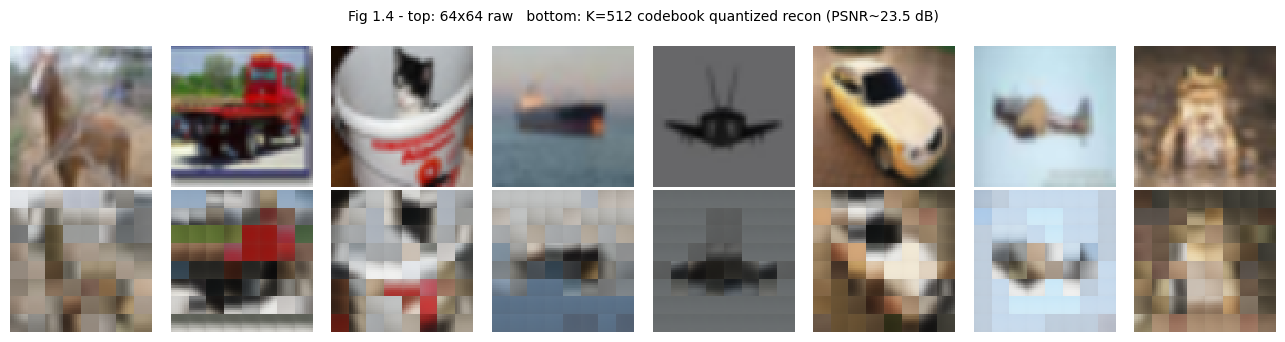

一句话说明：重构保留整体结构但丢失细节——这就是离散 token 化付出的代价。


In [12]:
# 原图 vs 量化重构
idx = np.random.RandomState(1).choice(len(test_x32), 8, replace=False)
orig = upsample_batch(test_x32[idx]).cpu(); rec = detokenize(test_tokens[idx]).cpu()
fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for j in range(8):
    axes[0, j].imshow(orig[j].permute(1, 2, 0).clamp(0, 1), interpolation="nearest"); axes[0, j].axis("off")
    axes[1, j].imshow(rec[j].permute(1, 2, 0), interpolation="nearest"); axes[1, j].axis("off")
fig.text(0.5, 0.96, f"Fig 1.4 - top: 64x64 raw   bottom: K={CFG['vocab_k']} codebook quantized recon "
         f"(PSNR~{qpsnr:.1f} dB)", ha="center")
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()
print("一句话说明：重构保留整体结构但丢失细节——这就是离散 token 化付出的代价。")

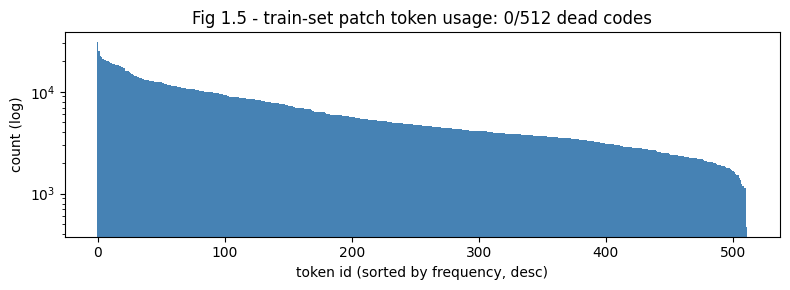

一句话说明：最高频 token 占全部 patch 的 1.0%，分布偏斜会影响 Transformer 的类别不平衡（交叉熵）。


In [13]:
# patch token 使用分布（死码 / 利用率）
counts = torch.bincount(train_tokens[:, 1:].reshape(-1).long(),
                        minlength=CFG["vocab_k"]).numpy()
dead = int((counts == 0).sum())
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(CFG["vocab_k"]), np.sort(counts)[::-1], width=1.0, color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("token id (sorted by frequency, desc)"); ax.set_ylabel("count (log)")
ax.set_title(f"Fig 1.5 - train-set patch token usage: {dead}/{CFG['vocab_k']} dead codes")
plt.tight_layout(); plt.show()
print(f"一句话说明：最高频 token 占全部 patch 的 {counts.max()/counts.sum():.1%}，"
      f"分布偏斜会影响 Transformer 的类别不平衡（交叉熵）。")

### 1.5 正弦位置编码

标准 Transformer 正弦编码，覆盖 65 个位置（0=BOS，1..64=raster patch）。生成顺序通过位置编码
注入——这也是里程碑 4「生成顺序」探究的关键钩子。

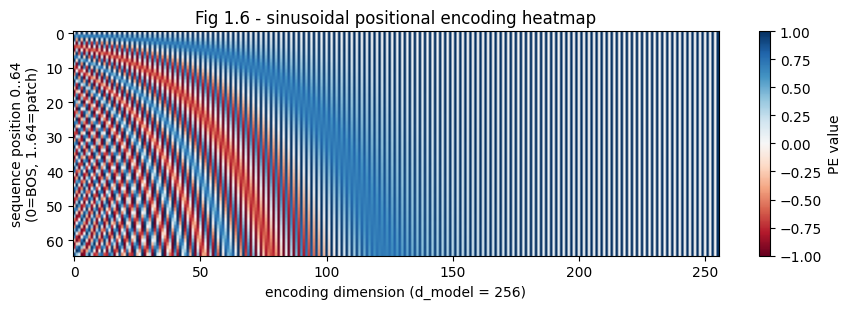

一句话说明：低维（左）随位置缓变、高维（右）快变，给每个生成步一个唯一可区分的位置签名。


In [14]:
def sinusoidal_pe(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
    return pe

PE = sinusoidal_pe(CFG["seq_len"], CFG["d_model"])
torch.save(PE, ART/"pos_encoding.pt")
fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(PE.numpy(), aspect="auto", cmap="RdBu")
ax.set_xlabel(f"encoding dimension (d_model = {CFG['d_model']})")
ax.set_ylabel("sequence position 0..64\n(0=BOS, 1..64=patch)")
ax.set_title("Fig 1.6 - sinusoidal positional encoding heatmap")
fig.colorbar(im, ax=ax, label="PE value")
plt.tight_layout(); plt.show()
print("一句话说明：低维（左）随位置缓变、高维（右）快变，给每个生成步一个唯一可区分的位置签名。")

### 1.6 阶段 1 小结

本节产出（缓存于 `artifacts/`，供后续阶段直接加载）：

| 产物 | 文件 | 形状 / 含义 |
|------|------|------|
| patch 词表 | `codebook_k512.npy` | `(512, 192)` K-means 质心 |
| 训练 token | `train_tokens.pt` | `(50000, 65)` int16，第 0 列 BOS |
| 测试 token | `test_tokens.pt` | `(10000, 65)` int16 |
| 位置编码 | `pos_encoding.pt` | `(65, 256)` 正弦 |
| 标签 | `train_y.npy` / `test_y.npy` | 供类条件探究备用 |

**关键数字 — 量化上限：** 测试集重构 PSNR ≈ 见上（`图 1.4`）。这是因果 Transformer 样本质量的
天花板，阶段 3 与 VAE 对比时要拿它做参照。

**交接阶段 2：** 输入序列 = `tokens[:, :-1]`（BOS..patch63），预测目标 = `tokens[:, 1:]`
（patch0..patch63）；词表大小 513，在其上做 softmax。下一步实现带因果掩码的 Transformer，并
做「无未来 token 泄漏」测试。

## 阶段 2 — 因果 Transformer（预测下一个 patch token）

把阶段 1 的 token 序列喂给一个 **GPT 式因果 Transformer**，训练它「用 patch 0..t 预测 patch t+1」。
本阶段交付（对应作业评分里程碑 1）：

1. **显式因果掩码** + **无未来 token 泄漏测试**（核心评分项）：既做确定性不变量测试，也做掩码消融。
2. **训练损失曲线**（train/val 随 epoch 下降）。
3. **下一 patch 预测合理性面板**（留出验证序列上的 teacher-forced 预测）。

> 训练用 `输入 = tokens[:, :-1]`（BOS..patch62），`目标 = tokens[:, 1:]`（patch0..patch63），
> 在 513 词表上做交叉熵。`epochs / batch_size` 记在 `TRAIN_CFG`，**阶段 4 的 VAE 必须复用同一组**
> 以保证对比公平。

### 2.1 模型定义（因果 patch Transformer = 图像版 GPT）

结构与 GPT 相同：`token 嵌入 + 正弦位置编码 → N 个 [因果自注意力 + MLP] 残差块 → LayerNorm
→ 线性头(→513)`。自注意力里**显式构造因果掩码**（上三角置 `-inf`），并留一个 `causal` 开关——
关掉它就能做泄漏消融。`return_attn=True` 可返回各层注意力权重，供阶段 3 画注意力时间线。

In [ ]:
import torch.nn as nn

# 模型超参（可调；属于我的设计选择，PDF 未规定）
MCFG = dict(n_layer=6, n_head=8, d_ff=4*CFG["d_model"], dropout=0.1,
            block_size=CFG["seq_len"]-1)        # 64 = 输入长度（tokens[:, :-1]）

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_head, dropout):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head, self.hd = n_head, d_model // n_head
        self.qkv  = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, causal=True, return_attn=False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.hd).transpose(1, 2)      # (B, nh, T, hd)
        k = k.view(B, T, self.n_head, self.hd).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.hd).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.hd)        # (B, nh, T, T)
        if causal:                                                  # ← 显式因果掩码
            future = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
            att = att.masked_fill(future, float("-inf"))
        att = att.softmax(dim=-1)
        out = self.drop(att) @ v                                    # (B, nh, T, hd)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return (self.proj(out), att) if return_attn else (self.proj(out), None)

class Block(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_head, dropout)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x, causal=True, return_attn=False):
        a, att = self.attn(self.ln1(x), causal=causal, return_attn=return_attn)
        x = x + a
        x = x + self.mlp(self.ln2(x))
        return x, att

class PatchGPT(nn.Module):
    def __init__(self, vocab_size, d_model, block_size, n_layer, n_head, d_ff, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pe", sinusoidal_pe(block_size, d_model))   # 复用阶段1的正弦编码
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_head, d_ff, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, causal=True, return_attn=False):
        B, T = idx.shape
        x = self.drop(self.tok_emb(idx) + self.pe[:T])
        attns = []
        for blk in self.blocks:
            x, att = blk(x, causal=causal, return_attn=return_attn)
            if return_attn: attns.append(att)
        logits = self.head(self.ln_f(x))
        return (logits, attns) if return_attn else logits

def build_model():
    return PatchGPT(CFG["vocab_size"], CFG["d_model"], MCFG["block_size"],
                    MCFG["n_layer"], MCFG["n_head"], MCFG["d_ff"], MCFG["dropout"]).to(DEVICE)

torch.manual_seed(SEED)
model = build_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"PatchGPT: {n_params/1e6:.2f}M 参数 | layers={MCFG['n_layer']} heads={MCFG['n_head']} "
      f"d_model={CFG['d_model']} block_size={MCFG['block_size']} vocab={CFG['vocab_size']}")

### 2.2 因果掩码：显式实现与可视化

因果掩码是一个 `T×T` 矩阵：位置 i（query，正在预测的 token）只能看位置 j ≤ i（key，已生成的
token）。下三角（含对角）可见、上三角（未来）被置 `-inf`，softmax 后未来位置权重恰为 0。下图把
「可见 / 屏蔽」画出来。

In [ ]:
T = MCFG["block_size"]
allowed = (~torch.triu(torch.ones(T, T), diagonal=1).bool()).float()   # 1=可见, 0=屏蔽
fig, ax = plt.subplots(figsize=(4.8, 4.4))
im = ax.imshow(allowed, cmap="Greys", interpolation="nearest")
ax.set_xlabel("key position j (attended-to token)")
ax.set_ylabel("query position i (current token)")
ax.set_title("Fig 2.1 - causal mask (white = visible j<=i, black = blocked future j>i)")
fig.colorbar(im, ax=ax, ticks=[0, 1], label="0=blocked   1=visible")
plt.tight_layout(); plt.show()
print("一句话说明：每行 i 只有 j≤i 为白（可见），上三角全黑——保证预测位置 i 时看不到未来。")

### 2.3 训练 / 验证数据准备

从 50000 条训练序列里随机留出 2000 条做验证（held-out），其余训练。`run_epoch` 跑一个 epoch
（传 `opt` 则训练、否则只评估），后面训练和消融都复用它。

In [ ]:
# 留出验证集（held-out）+ 训练辅助函数
N = train_tokens.shape[0]
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(N, generator=g)
val_idx, tr_idx = perm[:2000], perm[2000:]
train_seqs = train_tokens[tr_idx].long()     # (48000, 65)
val_seqs   = train_tokens[val_idx].long()    # (2000, 65)
print("train_seqs", tuple(train_seqs.shape), "| val_seqs", tuple(val_seqs.shape))

def make_batches(seqs, bs, shuffle, gen=None):
    order = torch.randperm(len(seqs), generator=gen) if shuffle else torch.arange(len(seqs))
    for i in range(0, len(seqs), bs):
        yield seqs[order[i:i+bs]]

def run_epoch(model, seqs, bs, opt=None, causal=True, gen=None):
    train = opt is not None
    model.train(train)
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in make_batches(seqs, bs, shuffle=train, gen=gen):
            batch = batch.to(DEVICE)
            inp, tgt = batch[:, :-1], batch[:, 1:]
            logits = model(inp, causal=causal)
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1))
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(batch); n += len(batch)
    return tot / n

### 2.4 无未来 token 泄漏测试（核心评分项）

两个层面证明「预测位置 i 时，模型看不到 i 之后的 token」：

- **测试 A — 确定性不变量（最严格）**：固定输入，**篡改某个未来位置 j 的 token**，重算 logits。
  带因果掩码时，位置 `< j` 的输出**逐位不变**（数值差 ≈ 0）；去掉掩码则会变。这在**随机初始化**
  的模型上就成立——证明的是*结构*，与训练无关。
- **测试 B — 掩码消融的后果**：去掉掩码训练，训练损失**迅速坍塌到接近 0**——模型直接从未来
  位置「抄答案」（因为目标 `p_t` 就摆在输入的下一个位置）。但这种模型在生成时无未来可抄，毫无用处。

In [ ]:
# 测试 A：确定性不变量——篡改未来 token 不应改变更早位置的输出（与训练无关，验证结构）
model.eval()
T = MCFG["block_size"]
x  = val_seqs[:8, :T].clone().to(DEVICE)
j  = 40                                            # 篡改位置 j 的 token
x2 = x.clone()
x2[:, j] = (x2[:, j] + 7) % CFG["vocab_k"]         # 换成另一个 patch token
with torch.no_grad():
    base_c, pert_c = model(x, causal=True),  model(x2, causal=True)
    base_n, pert_n = model(x, causal=False), model(x2, causal=False)
chg_before_causal = (base_c[:, :j] - pert_c[:, :j]).abs().max().item()
chg_after_causal  = (base_c[:, j:] - pert_c[:, j:]).abs().max().item()
chg_before_nomask = (base_n[:, :j] - pert_n[:, :j]).abs().max().item()
print(f"[因果掩码] 位置 <{j}  最大 logits 变化 = {chg_before_causal:.2e}  (应≈0：无泄漏)")
print(f"[因果掩码] 位置 >={j} 最大 logits 变化 = {chg_after_causal:.2e}  (应>0：理应受影响)")
print(f"[去掉掩码] 位置 <{j}  最大 logits 变化 = {chg_before_nomask:.2e}  (>0：未来信息泄漏！)")
assert chg_before_causal < 1e-4, "因果掩码失效：更早位置受到了未来 token 影响！"
assert chg_before_nomask > 1e-4, "对照失败：去掉掩码本应泄漏"
print("✓ 测试 A 通过：带因果掩码时，未来 token 不影响更早位置的预测（无泄漏）。")

In [ ]:
# 测试 B：掩码消融——去掉掩码训练损失会坍塌（模型从未来位置抄答案）
def quick_train(causal, steps=300, bs=256, lr=3e-4):
    torch.manual_seed(SEED)
    m = build_model(); opt = torch.optim.AdamW(m.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(SEED); hist = []; it = 0
    m.train()
    while it < steps:
        for batch in make_batches(train_seqs, bs, shuffle=True, gen=gen):
            batch = batch.to(DEVICE); inp, tgt = batch[:, :-1], batch[:, 1:]
            logits = m(inp, causal=causal)
            loss = F.cross_entropy(logits.reshape(-1, CFG["vocab_size"]), tgt.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
            hist.append(loss.item()); it += 1
            if it >= steps: break
    return hist

hist_causal = quick_train(causal=True)
hist_nomask = quick_train(causal=False)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_causal, label="with causal mask (correct)")
ax.plot(hist_nomask, label="no mask (leaks future)")
ax.set_xlabel("training step"); ax.set_ylabel("train loss (nats)")
ax.set_title("Fig 2.2 - ablating the causal mask collapses train loss (cheating)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"一句话说明：去掉掩码后 ~300 步训练损失降到 {hist_nomask[-1]:.3f}（接近 0），"
      f"而带掩码为 {hist_causal[-1]:.3f}——前者直接从未来位置抄答案，生成时无未来可抄、毫无用处。")

### 2.5 训练因果 Transformer

AdamW + 交叉熵，记录每 epoch 的 train/val 损失与墙钟时间（阶段 4 对比训练速度要用）。已有检查
点则直接加载（`artifacts/patchgpt.pt`）。在 4090 上这个小模型每 epoch 仅几秒。

In [ ]:
TRAIN_CFG = dict(epochs=30, batch_size=256, lr=3e-4, weight_decay=0.01)   # 阶段4 VAE 复用 epochs/batch_size
CKPT = ART / "patchgpt.pt"
if CKPT.exists():
    state = torch.load(CKPT, map_location=DEVICE)
    model.load_state_dict(state["model"]); history = state["history"]
    print(f"已加载训练好的 PatchGPT（{len(history['train'])} epochs）")
else:
    opt = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["lr"],
                            weight_decay=TRAIN_CFG["weight_decay"])
    gen = torch.Generator().manual_seed(SEED)
    history = {"train": [], "val": [], "epoch_time": []}
    for epn in range(TRAIN_CFG["epochs"]):
        t0 = time.time()
        tr = run_epoch(model, train_seqs, TRAIN_CFG["batch_size"], opt=opt, causal=True, gen=gen)
        va = run_epoch(model, val_seqs,   TRAIN_CFG["batch_size"], opt=None, causal=True)
        dt = time.time() - t0
        history["train"].append(tr); history["val"].append(va); history["epoch_time"].append(dt)
        print(f"epoch {epn+1:02d}/{TRAIN_CFG['epochs']}  train {tr:.4f}  val {va:.4f}  ({dt:.1f}s)")
    torch.save({"model": model.state_dict(), "history": history, "train_cfg": TRAIN_CFG}, CKPT)
    print(f"训练完成，平均每 epoch {np.mean(history['epoch_time']):.1f}s")

### 2.6 训练损失曲线

In [ ]:
ep = range(1, len(history["train"]) + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ep, history["train"], marker=".", label="train")
ax.plot(ep, history["val"],   marker=".", label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss (nats)")
ax.set_title("Fig 2.3 - PatchGPT training / validation loss")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
avg_t = float(np.mean(history["epoch_time"])) if history["epoch_time"] else float("nan")
print(f"一句话说明：train/val 损失随 epoch 下降并趋稳；最终 val={history['val'][-1]:.3f} nats，"
      f"平均每 epoch {avg_t:.1f}s（阶段4 与 VAE 比训练速度的基准）。")

### 2.7 下一 patch 预测合理性面板（留出序列）

在留出验证集上做 **teacher-forced** 预测：喂入真实前缀，模型在每个位置预测下一个 patch（每个
位置因果地只看自己的过去）。把每个位置的 top-1 预测拼成一张图，与 GT 量化图对比，并报告下一
patch 的 top-1 准确率。预测图越接近 GT，说明模型越懂 patch 间的空间/上下文规律。

In [ ]:
@torch.no_grad()
def teacher_forced_pred(model, seqs, bs=1000):
    model.eval(); outs = []
    for i in range(0, len(seqs), bs):
        logits = model(seqs[i:i+bs, :-1].to(DEVICE), causal=True)   # (b,64,vocab)
        outs.append(logits.argmax(-1).cpu())
    return torch.cat(outs)                                          # (N,64) 预测 p0..p63

pred_val = teacher_forced_pred(model, val_seqs)
acc = (pred_val == val_seqs[:, 1:]).float().mean().item()

n_show = 6
gt_img = detokenize(val_seqs[:n_show]).cpu()
pred_full = torch.cat([torch.full((n_show, 1), CFG["bos_id"], dtype=torch.long),
                       pred_val[:n_show].long()], 1)               # 补一个 BOS 占位以复用 detokenize
pred_img = detokenize(pred_full).cpu()
fig, axes = plt.subplots(2, n_show, figsize=(11, 3.8))
for j in range(n_show):
    axes[0, j].imshow(gt_img[j].permute(1, 2, 0), interpolation="nearest"); axes[0, j].axis("off")
    axes[1, j].imshow(pred_img[j].permute(1, 2, 0), interpolation="nearest"); axes[1, j].axis("off")
fig.text(0.5, 0.97, "Fig 2.4 - held-out next-patch prediction (teacher-forced)   "
         "top: GT quantized   bottom: model 1-step prediction", ha="center")
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()
print(f"一句话说明：留出验证集上下一 patch 的 top-1 准确率 = {acc:.1%}；"
      f"预测图与 GT 量化图整体相似，说明模型学到了 patch 间的上下文规律（而非乱猜）。")

### 2.8 阶段 2 小结

- **产出**：训练好的 `PatchGPT`（`artifacts/patchgpt.pt`）、训练/验证损失曲线（`Fig 2.3`）、
  **已验证无未来 token 泄漏**（`Fig 2.2` + 测试 A 断言）、留出集下一 patch 预测面板（`Fig 2.4`）。
- **公平性提醒**：`TRAIN_CFG` 的 `epochs / batch_size` 是阶段 4 VAE 必须**复用**的基准。
- **交接阶段 3**：用这个模型做自回归采样（从 `[BOS]` 逐 patch 生成 20 张图），并用
  `model(..., return_attn=True)` 取每步注意力权重，画 5 张图的注意力时间线。